# **Laboratorio 3 - Intervalos de Confianza y Test de Hipótesis**

In [1]:
import pandas as pd #Para manejar los datos con tablas
import seaborn as sns #Para realizar gráficas estadisticas
import matplotlib.pyplot as plt #Graficos básicos
import scipy.stats as stats
from scipy.stats import linregress
import numpy as np
import random
ur = 'https://raw.githubusercontent.com/ivanordenes/analisis-datos/refs/heads/main/Life%20Expectancy%20Data.csv' #URL dataset seleccionado

df_original = pd.read_csv(ur)
df=pd.read_csv(ur) #Lee archivo .csv desde la URL y lo guarda

df_copia = pd.DataFrame(df) #Copia dataframe

print(len(df))   #Limpieza outliers
columnas_analizar = [
    'Life expectancy ',
    'Schooling',
    'Income composition of resources'

]

for columna in columnas_analizar:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    df = df[(df[columna] >= limite_inf) & (df[columna] <= limite_sup)]
print(len(df))

2938
2615


## Intervalos de confianza y Ajuste de bondad

### 1. Intervalo de Confianza

#***Media IDH***

### Para calcular de forma satisfactoria el Intervalo de confianza, reconocemos el nivel de confianza dado en el enunciado, el cual es 95,4%, sabemos que nuestro nivel de confianza esta dado por la forma dada:

$P(Θ\in [\theta_1,\theta_2])=1-α$

$P(\theta\in [\theta_1,\theta_2])=0,954$

$1-α = 0,954$

$1-α = 0,954$

$α = 0,046$
###Que corresponde a nuestro nivel de significación del intervalo de confianza que se
### Tambien recordamos del laboratorio anterior, que los resultados graficos de el metodo boostrap, se asimilaban a una distribución normal, ya que se tiene en poder una gran cantidad de datos, para ser exactos, se manipularon 2615 datos a la hora de usar el estimador mediante boostrap (Suficientes para hacer que nuestra distribucion t-student generada sea parecida a la normal estandarizada), esto en materia de intervalos de confianza, al tener varianza desconocida, caso en el cual se utiliza una distribucion t-student para calcular los intervalos de confianza y calcular la desviacion estandar con los datos proporcionados:
$[\bar{X}-t_{α/2}^{n-1}\frac{S}{\sqrt{n}},\bar{X}+t_{α/2}^{n-1}\frac{S}{\sqrt{n}}]$

In [3]:
np.random.seed(67)
resultados={}  #Diccionario con diferentes estadisticos
resultados['media']=[]
resultados['desviacion_est']=[]
resultados['mediana']=[]
columna = df['Income composition of resources'].dropna()
def boostrap(colmn, result):
    lista_grande=colmn.tolist()  #Pone los valores de la columna en una lista


    for i in range(10000):
      muestra=np.random.choice(colmn, size=len(colmn), replace=True)  #Muestra de largo de la lista, con elementos elegidos de forma aleatoria
      result['media'].append(np.mean(muestra))
      result['desviacion_est'].append(np.std(muestra))
      result['mediana'].append(np.median(muestra))

boostrap(columna, resultados)
#Ahora falta calcular los intervalos de confianza
n=len(columna)
media_datos=np.mean(columna)
S=np.std(columna, ddof=1)

confianza=0.954
alpha= 1-confianza

#Ahora hay que encontrar el valor de la t-student, el cual no podremos sacar de las tablas de internet ya que los grados de libertad es un valor muy alto, sobrepasando las 2000 unidades, por
#lo que se calculara con python
valor_t_std = stats.t.ppf(1 - alpha / 2, df=n-1)

Limite_inf= media_datos - valor_t_std *(S / np.sqrt(n))
Limite_sup=media_datos + valor_t_std *(S / np.sqrt(n))

print("El intervalo de confianza va desde ",Limite_inf, " hasta ",Limite_sup)

El intervalo de confianza va desde  0.6547103913261874  hasta  0.6672115972015373


#***Resultados***
###Con los resultados obtenidos, con un metodo boostrap que utiliza 10000 repeticiones y mas de 2000 datos, en la cual se utilizo la distribucion t-student por la varianza desconocida, se puede observar de forma sencilla el intervalo de confianza al 95,4% para la media del IDH es:

$[0.6547,6672]$

###Por lo que si se calcula el promedio del IDH 100 veces el 95,4% de las veces deberia estar en el intervalo dado.

#***Razon de cambio entre Los años de escolaridad y la expectativa de vida***
###En este caso, sabemos que nuestro parametro no tiene una forma clara de calcularlo porque no hay una cantidad pivotal clara, por lo que utilizaremos los percentiles del metodo de boostrap para acercanos a los valores que buscamos.
###Como generamos 10000 muestras, simplemente se extraeran los percentiles segun el alpha dado anteriormente.

$$\text{IC} = \left[ P_{\alpha/2}, \;\; P_{1 - \alpha/2} \right] = \left[ P_{0.023}, \;\; P_{0.977} \right]$$

In [2]:
np.random.seed(67)
Pendientes=[]
media=df_original['Income composition of resources'].mean()
df_sobreprom=df_original[df_original['Income composition of resources']>media]

def boostrap_part2(df_ej,colmn,otracolm, result):  #Funcion que utiliza el metodo con la pendiente entre dos variables
    df_pend=df_ej[[colmn, otracolm]].dropna().values #Crea una tupla con los valores de las dos columnas

    for i in range(10000):
      indices_rd=np.random.choice(len(df_pend), size=len(df_pend), replace=True)  #Seleccion de diferentes indices aleatorios
      muestra=df_pend[indices_rd]    #Segun los indices va sacando las tuplas
      pendiente= np.polyfit(muestra[:,0], muestra[:,1],1)[0] #Calcula la pendiente utilizando los valores de la tupla mas el intercepto, [0] es para obtener solo la pendiente
      result.append(pendiente)
boostrap_part2(df_sobreprom,'Schooling','Life expectancy ',Pendientes )

#Confianza y alpha
confianza = 0.954
alpha = 1 - confianza

#Calculo de percentiles
percentil_inferior = (alpha / 2) * 100
percentil_superior = (1 - alpha / 2) * 100

#Limites de el intervalo de confianza
limite_inf_pendiente = np.percentile(Pendientes, percentil_inferior)
limite_sup_pendiente = np.percentile(Pendientes, percentil_superior)

print("El intervalo de confianza de la pendiente de los años de escolaridad y la expectativa de vida es: ",limite_inf_pendiente, " hasta ",limite_sup_pendiente)
print("El numero de datos de paises que superan el promedio son",len(df_sobreprom['Income composition of resources']))

El intervalo de confianza de la pendiente de los años de escolaridad y la expectativa de vida es:  1.4661053956542787  hasta  1.647840456257874
El numero de datos de paises que superan el promedio son 1633


#***El intervalo de confianza de la pendiente***
###Como se pudo notar, con el metodo boostrap con 10000 repeticiones, se puede obtener un intervalo de confianza a traves de los percentiles, se puede observar el intervalo de confianza al 95,4% para la pendiente entre ambas variables es:
$[1.467,1.647]$
###Por lo que este corresponde a nuestro intervalo con 95,4% de
###Tambien se puede decir que por cada año mas de escolaridad entre los paises sobre el promedio, se aumentara la expectativa de vida entre un 1.46 a un 1.64 años de vida.


#***Es este Intervalo de confianza influyente en lo que queremos buscar***
###Haciendo un pequeño analisis, sobre los intervalos de confianza obtenidos y su significado, Podemos notar la importancia de ambos intervalos ya que, a traves de la media del IDH, se puede ver desde que valores se pueden filtrar los paises para llevar a cabo la pendiente, que es nuestro segundo parametro en el cual calculamos el intervalo de confianza y con el cual podemos tomar analisis de nuestra pregunta:

###Media IDH: Podemos notar que es un intervalo bastante angosto, por lo que no tiene muchos valores posibles tomando en cuenta los valores que puede tomar el IDH, La diferencia entre sus limites corresponde a 0,0125 esto corresponde solo al 1,25% del rango posible que puede tomar el IDH, por lo que se puede afirmar que es angosto, pero sirve para tener un valor promedio del IDH acertado.Este es un parametro vital en nuestro Laboratorio ya que, es el filtro mas importante a llevar a cabo para poder estudiar la relacion entre los años de escolaridad y la expectativa de vida.

###Pendiente Años de escolaridad vs Expec. de vida: Esta es la información principal con la que trabajamos, ya que es de donde salen los datos con los que queremos responder la hipotesis efectuada, se puede notar principalmente que la pendiente toma valores positivos en sus limites, tambien que este tiene un rango medio, ya que no varian tanto los años de vida, solo se diferencian entre 0,18 años de vida que corresponden a un par de meses de vida.
###Lo mas importante que se rescato de este intervalo de confianza, es que ya sabemos que al un año mas de educacion en un pais que tiene el IDH sobre el promedio, la expectativa de vida aumentara, que es algo de lo que se queria responder, ¿Como afectarian los años de vida?, ahora podemos saber que los años de vida aumentan.

#***Nivel de incertidumbre. Indique cuántos datos adicionales se necesitarían para reducir dicha incertidumbre en un 55 %, manteniendo el nivel de significancia fijo.***
###Como sabemos la significancia es parte del ancho de el intervalo de confianza:
###Para la incertidumbre de la media del IDH= $t_{α/2}^{n-1}\frac{S}{\sqrt{n}}$
###Si queremos que el nivel de significancia este fijo, debemos modificar la cantidad de datos que estamos tomando en cuenta

In [4]:
print("El numero de datos son",n)
incertidumbre=valor_t_std *(S / np.sqrt(n))
print("Incertidumbre presentada en la media del IDH",incertidumbre)

El numero de datos son 2615
Incertidumbre presentada en la media del IDH 0.006250602937674956


###Incertidumbre de la media del IDH = 0.00625, Queremos reducir en un 55% la incertidumbre por lo que haremos el calculo correspondiente, sabiendo que los datos en un principio eran 2615:
$ t_{α/2}^{n-1}\frac{S}{\sqrt{n_1}}* 0.45= t_{α/2}^{n-1}\frac{S}{\sqrt{n_2}}$

$\frac{S}{\sqrt{n_1}}* 0.45=\frac{S}{\sqrt{n_2}}$

$\sqrt{n_2}*0.45 =\sqrt{n_1}$  

$n_1=2615$

$n_2*0.2025 = 2615$

$n_2= 12914$
###La cantidad de datos necesaria es 12.914 datos nuevos para bajar la incertidumbre un 55% manteniendo el nivel de significancia.

##***Incertidumbre pendiente:***
###La incertidumbre de la pendiente por su parte al no ser calculado por cantidad pivotal, corresponde al ancho de su intervalo que corresponde a 0.18, en este caso, sucede algo parecido a la media:

$n_1*4.93=n_2$

$n_2=8050$

###Necesitamos 5 veces aproximadamente la cantidad de datos actuales, para poder reducir el intervalo de confianza en un 55%.

#***Calcule el nivel de significancia necesario para reducir la incertidumbre en un 55 %, manteniendo fijo el tamaño muestral.***
###Ahora modificando nuestro nivel de significancia, sabemos que α = 0,046, y el valor utilizado en la t-student esta rondando las 2 unidades, ahora tenemos que modificar nuestro valor de la t-studen, variando el coeficiente α para que sea el 45% del .

In [5]:
nuevo_t= valor_t_std * 0.45  #Nuevo valor de la t-student
print("El nuevo valor de la distribucion t-student",nuevo_t)
probabilidad_acumulada = stats.t.cdf(nuevo_t, df=2615)   #Probabilidad acumulada en las colas nuestro nuevo valor
nuevo_alpha = 2 * (1 - probabilidad_acumulada)    #Nuevo alpha calculado de forma inversa.
nueva_confianza = 1 - nuevo_alpha
print("El nuevo nivel de confianza es: ",nueva_confianza, ", mientras que nuestro nuevo alpha corresponde a: ", nuevo_alpha)

El nuevo valor de la distribucion t-student 0.8983549924556063
El nuevo nivel de confianza es:  0.6309209704256042 , mientras que nuestro nuevo alpha corresponde a:  0.36907902957439576


#***Significancia pendiente α***
###En el caso de la significancia, habria que modificar lo que son, los percentiles tomados en un principio, los cuales cambiarian, aumentando a la misma cantidad que en la media del IDH, teniendo los percentiles ahora entre el 18.4 y 81.6

In [ ]:
percentil_inferior = (0.368/ 2) * 100
percentil_superior = (1 - 0.368 / 2) * 100

limite_inf_pendientes = np.percentile(Pendientes, percentil_inferior)
limite_sup_pendientes = np.percentile(Pendientes, percentil_superior)
print("Los nuevos limites son son: [",limite_inf_pendientes,",", limite_sup_pendientes,"]")

Los nuevos limites son son: [ 1.514594352547778 , 1.5966080470014996 ]


#***Cual de estos metodos es mas viable***
###Tomando en cuenta los calculos hechos y las condiciones que provocan los cambios dados, se hara un pequeño analisis de cada uno:

##***Aumento de datos:***
###En el caso de el aumento de datos, podemos notar que del calculo llevado a cabo, se dio en cuenta que para reducir la incertidumbre un 55%, se necesitan 12914 y 8050 datos respectivamente, que son aproximadamente 5 veces la cantidad de datos, que tenemos en nuestro data set al momento de hacer el laboratorio, tomando en cuenta esto, sabiendo que nuestro dataset contiene datos de 15 años diferentes de cada pais, necesitariamos esperar 60 años para poder llevar a cabo la recoleccion de datos y bajar la incertidumbre en un 55%, lo que es muy dificil si queremos hacer un analisis en el corto plazo, la otra forma de verlo seria buscar datos de los paises desde hace 60 años, con lo cual no tendriamos la certeza de poder obtener estos, datos ya que en la actualidad no todos los paises presentan datos, es mas dificil que hace 60 años lo hicieran, hasta los que los cumplen a dia de hoy.

##***Cambio de significancia:***
###En el caso del cambio de significancia, terminamos con un intervalo que opera al 0.63% de confianza segun los calculos realizados, por lo que en este caso, sacrificamos la mayoria de la confianza que teniamos en un principio, ya que tenemos mas de un 30% decaimiento en el coeficiente, por lo que en este caso seria mas dificil que el parametro caiga en nuestro intervalo, haciendo que nuestras estimaciones fallen mas de lo deseado, aprox 4 de cada 10 veces.

###Conclusion: Tomando las dos consideraciones anteriormente dadas, debemos comparar lo que pasa en ambos casos, ya que en el caso de el aumento de datos, deberiamos esperar demasiado tiempo para tener la cantidad deseada lo que se nos haria inutil en cierto punto porque en 60 años no sabemos si necesitamos aun el estudio con los datos, mientras que el cambio de significancia seria algo mas rapido y mas posible, pero haria que nuestras estimaciones fueran muy erraticas, por lo que una gran cantidad de veces, simplemente errariamos y no podriamos hacer una buena estimación, por lo que en este caso, lo mejor seria hacer el cambio de significancia y verificar arduamente los parametros estimados, ya que la otra opcion tiene un costo fisico demasiado grande para ser llevado a cabo.

### 2. Prueba de bondad






#***Prueba de bondad elegida***
###Después de investigar cada una de las pruebas de bondad, pudimos concluir que la mas acertada era la de Anderson-Darling. Al ser nuestra variable continua teníamos la opción de Kolmogorov-Smirnov o Anderson-Darling, sin embargo, al investigar descubrimos que Anderson-Darling es superior cuando los parámetros poblacionales (media, varianza) son desconocidos y deben ser estimados en este caso por la muestra del Bootstrap. Cabe acotar que se podía hacer con Kolmogorov-Smirnov, pero se debía hacer la corrección de Lilliefors.

#***Nivel de significancia***
###Para mantener la coherencia con la sección de intervalos de confianza, nuestro nivel de significancia teórico es de $\alpha = 0.046$ (derivado del 95.4% de confianza). Sin embargo, la función anderson de la librería scipy.stats evalúa contra niveles críticos discretos predefinidos (15%, 10%, 5%, 2.5%, 1%). Por lo tanto, en la ejecución del código trabajamos con el nivel empírico más cercano: $\alpha = 0.05$ (5%).Trabajar con un $\alpha$ mayor (como 10%) en esta prueba de bondad nos haría más "estrictos", aumentando el riesgo de rechazar la normalidad de los datos por variaciones insignificantes (Error Tipo I). Al comprobar que nuestros datos aceptan $H_0$ al 5% (un % más estricto que nuestro 4.6% teórico), podemos asegurar matemáticamente que la distribución también cumple la normalidad para nuestro $\alpha = 0.046$.
#***Evaluacion de la distribucion propuesta***
###La distribucion propuesta paso la prueba en ambos casos sobrada, es decir, fue una excelente aproximacion, el valor critico (o limite de tolerancia) para un nivel de significancia del 5% en python, es de 0,784, a nosotros nos dio 0,1861 y 0,3778, al ambos valores ser mucho menores que 0,784, podemos determinar que fue una buena eleccion, y que ambas se comportan casi como un campana perfecta.

#***Conclusiones***
###Los resultados de la prueba de bondad de ajuste son consistentes con los intervalos de confianza, al confirmar con la prueba de Anderson-Darling que la distribución sigue una distribución normal (aceptando $H_0$ en ambos casos y con un estadístico de 0,3778 y 0,1861 respectivamente), demostramos que la distribución del estimador es simétrica y sin sesgos. Esto asegura que los intervalos de confianza son valido y que la incertidumbre es correcta en ambos casos es correcta.

In [6]:

#Prueba Anderson-Darling: Media IDH
resultado_media = stats.anderson(resultados['media'], dist='norm')
print("Prueba Anderson-Darling: Media IDH")
print(f"Estadístico de prueba: {resultado_media.statistic:.4f}")
sl_5_m = resultado_media.significance_level[2]
cv_5_m = resultado_media.critical_values[2]
if resultado_media.statistic < cv_5_m:
    print(f"Al {sl_5_m}% de significancia: La distribución parece Normal (Se acepta H0)")
else:
    print(f"Al {sl_5_m}% de significancia: La distribución no parece Normal (Se rechaza H0)")
# Prueba Anderson-Darling: Pendientes
resultado_pendiente = stats.anderson(Pendientes, dist='norm')
print("Prueba Anderson-Darling: Pendientes")
print(f"Estadístico de prueba: {resultado_pendiente.statistic:.4f}")
sl_5_p = resultado_pendiente.significance_level[2]
cv_5_p = resultado_pendiente.critical_values[2]
if resultado_pendiente.statistic < cv_5_p:
    print(f"Al {sl_5_p}% de significancia: La distribución parece Normal (Se acepta H0)")
else:
    print(f"Al {sl_5_p}% de significancia: La distribución no parece Normal (Se rechaza H0)")

Prueba Anderson-Darling: Media IDH
Estadístico de prueba: 0.3778
Al 5.0% de significancia: La distribución parece Normal (Se acepta H0)
Prueba Anderson-Darling: Pendientes
Estadístico de prueba: 0.1861
Al 5.0% de significancia: La distribución parece Normal (Se acepta H0)


## Test de hipótesis

### 1. Primer test: comparación de medias
Primero, para que la hipótesis sea pertinente a la pregunta de investigación, es necesario aclarar que trabajaremos con los datos especificados en ella; eso es, países con un IDH mayor a la media mundial.

In [7]:
media = df['Income composition of resources'].mean() #media del IDH
filtro = df[df['Income composition of resources'] >= media] #registros con un IDH mayor a esa media

df_filtro = pd.DataFrame(filtro)

Primero: Separamos en dos grupos la muestra; países con 12 o más años de educación promedio y países con menos de 12 años de educación promedio. Esto porque, de forma aproximada, representa el punto donde las personas terminan su educación secundaria (educación media como se denomina en Chile) por completo (asumiendo que, en promedio, las personas comienzan su educación a los 4 años, e ignorando también aquellos casos donde los años de educación se extienden por la necesidad de repetir un grado).

Como la pregunta de hipótesis cuestiona si la educación tiene un impacto en la esperanza de vida, y por lo desarrollado en las experiencias previas, creemos que ese impacto existe y es positivo, tomaremos como 'estado actual' (hipótesis $H_0$), el que dicho efecto no exista (las medias son iguales) o es lo contrario (la media del grupo con 12 o más años de educación es menor a la del grupo con menos de 12). Así:

--------------------------------------------------------------------------------
**Hipótesis:** La media de la distribución de esperanza de vida para aquellos países donde los años de educación promedio son 12 años o más (grupo 1) es mayor que para el resto de países, donde los años de educación promedio son menor a 12 (grupo 2).

Si llamamos a la media de esperanza de vida para el grupo 1: $\mu_{\ge12}$, y a la media de esperanza de vida para el grupo 2: $\mu_{<12}$, entonces, la hipótesis es:

$\textbf{$H_0$:}$ $\mu_{\ge12} \le \mu_{<12}$

$\textbf{$H_1$:}$ $\mu_{\ge12} > \mu_{<12}$

--------------------------------------------------------------------------------

Segundo: Se trabajará con una varianza desconocida, donde, además, las medias se compararán bajo heterocedasticidad (distinta varianza). En cuanto a supuestos, se asume que:

1. Las muestras para los grupos son independientes entre sí.
2. Los datos dentro de cada grupo son independientes.
3. Dado el alto volumen de datos, el Teorema del Límite Central nos permite asumir distribuciones aproximadamente normales para los grupos.

Dada la situación en la que nos encontramos, llevaremos al cabo el Test de Hipótesis como una Prueba T de Welch, de modo que utilizaremos el estadístico de contraste asociado a ella. Además, el nivel de significancia será $\alpha = 0,05$, para tener una región de aceptación del 95%.

--------------------------------------------------------------------------------
El estadístico de contraste para comprobar la hipótesis corresponde a:

$T =$ ${\overline X_1 - \overline X_2 - (\mu_{\ge12} - \mu_{<12})}
\over
{\sqrt{{ S_1^2 \over {n_1}} + {S_2^2 \over {n_2}}}}$
$\overset{\text{Bajo $H_0$}}{=}$ ${\overline X_1 - \overline X_2}
\over
{\sqrt{{ S_1^2 \over {n_1}} + {S_2^2 \over {n_2}}}}$, donde:

$\overline X_1$, $S_1$ y $n_1$ son la media, varianza y número de datos del grupo 1 (años de educación menor a 12), respectivamente.

Y $\overline X_2$, $S_2$ y $n_2$ son la media, varianza y número de datos del grupo 2 (años de educación menor a 12), respectivamente.

Además, el estadístico se distribuye de la forma: $T_\nu$, donde $\nu$ se calcula como:

$\nu = $ $\frac{
\left(
\frac{S_1^2}{n_1}
+
\frac{S_2^2}{n_2}
\right)^2
}{
\frac{\left(\frac{S_1^2}{n_1}\right)^2}{n_1-1}
+
\frac{\left(\frac{S_2^2}{n_2}\right)^2}{n_2-1}
}$

La región crítica para rechazar $H_0$ es:

$T_0$ > $t_{\alpha,\nu}$

Los supuestos serán:

1. Las muestras para los grupos son independientes entre sí.
2. Los datos dentro de cada grupo son independientes.
3. Dado el alto volumen de datos, el Teorema del Límite Central nos permite asumir distribuciones aproximadamente normales para los grupos.
--------------------------------------------------------------------------------

#### Ejecución y Resultados

1. Necesitamos dos sub-datasets para trabajar con los dos grupos.

In [8]:
#Grupo 1
doce_mas = df_filtro[df_filtro['Schooling'] >= 12.0]
df_doce_mas = pd.DataFrame(doce_mas)

#Grupo 2
menos_doce = df_filtro[df_filtro['Schooling'] < 12.0]
df_menos_doce = pd.DataFrame(menos_doce)

2. Debemos calcular $\overline X_1$, $S_1$ y $n_1$ para el grupo 1 (doce o más) y $\overline X_2$, $S_2$ y $n_2$ son la media, varianza y número de datos del grupo 2 (menos de doce).

In [9]:
x1 = df_doce_mas['Life expectancy '].mean()
s1 = df_doce_mas['Life expectancy '].var()
n1 = len(df_doce_mas)

print("Media de la esperanza de vida del grupo 1: " ,x1, "\nVarianza de la esperanza de vida del grupo 1: ",s1,"\nNúmero de datos del grupo 1: ",n1)

x2 = df_menos_doce['Life expectancy '].mean()
s2 = df_menos_doce['Life expectancy '].var()
n2 = len(df_menos_doce)

print("Media de la esperanza de vida del grupo 2: " ,x2, "\nVarianza de la esperanza de vida del grupo 2: ",s2,"\nNúmero de datos del grupo 2: ",n2)

Media de la esperanza de vida del grupo 1:  75.96219956300074 
Varianza de la esperanza de vida del grupo 1:  20.77146367151577 
Número de datos del grupo 1:  1373
Media de la esperanza de vida del grupo 2:  72.28282828282828 
Varianza de la esperanza de vida del grupo 2:  8.980416408987843 
Número de datos del grupo 2:  99


3. Calcular $T_0$

In [10]:
t0 = (x1-x2)/(np.sqrt(((s1**2)/(n1))+((s2**2)/(n2))))
print("T_0 es: ",t0)

T_0 es:  3.4629984458147263


4. Calcular $\nu$

In [11]:
#Para que sea menos confuso, ocuparemos variables temporales con valores que se repiten, como s1^2/n1 y s2^2/n2
var1 = (s1**2)/(n1)
var2 = (s2**2)/(n2)

var3 = (var1**2)/(n1-1)
var4 = (var2**2)/(n2-1)

nu = ((var1 + var2)**2)/(var3 + var4)
print("Los grados de libertad 'nu' son: ",nu)

Los grados de libertad 'nu' son:  186.21050171838803


5. Hallar $t_{\alpha,\nu}$

In [12]:
from scipy.stats import t
t_crit = t.ppf(0.95, df=nu) #la función ppf calcula el acumulado desde la izquierda, entonces queremos 1 - 0.05
print("El valor de la región crítica es: ",t_crit)

El valor de la región crítica es:  1.6530777841204898


6. Estadístico T bajo $H_0$ y $p$_$value$

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------


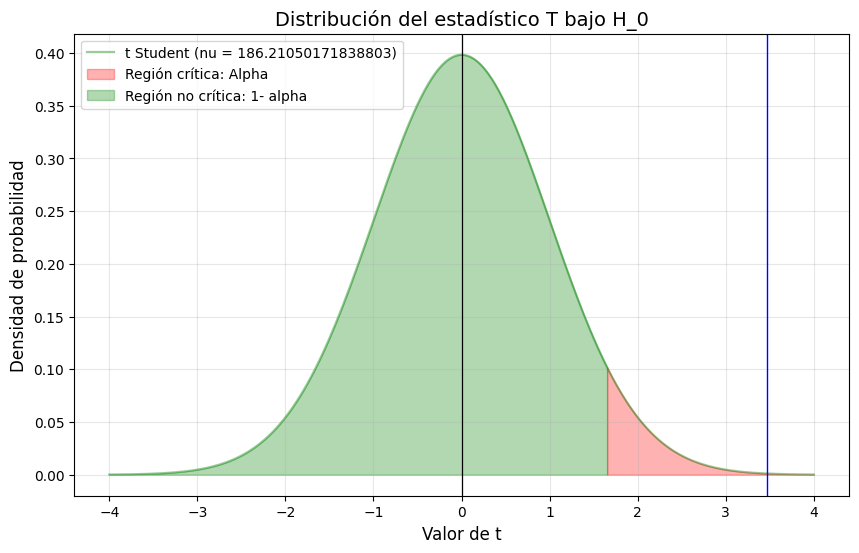

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [13]:
print('-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------')
x = np.linspace(-4, 4, 200)

y_t = t.pdf(x, nu)

plt.figure(figsize=(10, 6))
plt.plot(x, y_t, label=f't Student (nu = {nu})', color='green', linewidth=1.6,alpha=0.4)

plt.title('Distribución del estadístico T bajo H_0', fontsize=14)
plt.xlabel('Valor de t', fontsize=12)
plt.ylabel('Densidad de probabilidad', fontsize=12)
plt.axvline(0, color='black', linewidth=0.9)
plt.axvline(t0, color='blue', linewidth=1)

extremo_izquierdo = -4
extremo_derecho = 4

x_sombra_crit = np.linspace(extremo_derecho, t_crit, 500)
y_sombra_crit = stats.t.pdf(x_sombra_crit, df=nu)
plt.fill_between(x_sombra_crit, y_sombra_crit, color='red', alpha=0.3,
                 label=f'Región crítica: Alpha')
x_sombra = np.linspace(t_crit, extremo_izquierdo, 500)
y_sombra = stats.t.pdf(x_sombra, df=nu)
plt.fill_between(x_sombra, y_sombra, color='green', alpha=0.3,
                 label=f'Región no crítica: 1- alpha')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()
print('---------------------------------------------------------------------------------------------------------------------------------------------------------------------------')

In [ ]:
p_value = 1 - t.cdf(t0,df=nu)
print("El p_value es: ",p_value)

El p_value es:  0.0003313575234482613


Dado que $T_0$ > $t_{\alpha,\nu}$ -> 3.46 > 1,65:

Se rechaza $H_0$, ya que asumiendo que esta es verdadera, significaría que la muestra tiene una muy pequeña probabilidad de ocurrir dado ese supuesto, puesto que su p-value es 0,00033 -> 0,33%; o sea, un valor menor al nivel de significancia $\alpha$ = 0,05 -> 5%.

7. Errores tipo $I$ y $II$

En nuestro contexto, cometer un error de tipo $I$ significa rechazar la hipótesis $H_0$ dado que esta sea verdadera; en específico, sería ignorar o negar que los años de educación no tienen un impacto significativo positivo en la expectativa de vida cuando es así (que es lo mismo que asegurar que tienen dicho impacto cuando no es así).

Por otra parte, cometer un error de tipo $II$ significa no rechazar $H_0$ cuando esta no sea verdadera: creer que los años de escolaridad promedio no tienen un impacto positivo en la esperanza de vida cuando sí es así.

Dado el nivel de significancia dado $\alpha$ = 0,05, existe un 5% de probabilidad de cometer tanto el error tipo $I$ como el error tipo $II$ (o sea, cualquiera de los errores; naturalmente, sólo podemos cometer uno de ellos a la vez). En definitiva, creemos que es más grave cometer el error de Tipo $I$, ya que afirmamos algo que rechaza o va en contra del 'status-quo'; esto es, dejar la percepción de que la escolaridad no afecta en la expectativa de vida de las personas (creer que no se relacionan), y comenzar a afirmar que lo hace. El error de tipo $II$ sólo sería 'pasar por alto' información nueva a la que conocemos: sería como nunca saber que la educación influye positivamente en la esperanza de vida.

8. Varianza conocida vs desconocida

Al trabajar con varianza conocida, el estadístico de contraste se distribuye de una forma $\mathcal{N}(0,1)$, mientras que con varianza desconocida, se distribuye de la forma $\mathcal{T}_{\nu}$, donde $\nu$ varía su valor según se utilice homocedasticidad ($\nu$ = $n_1 + n_2 - 2$ = 1272) o heterocedasticidad ($\nu$ calculado previamente).

De esta forma, si asumimos un nivel de significancia $\alpha$ (sea 0,05 para este ejemplo) y hacemos un análisis uniletareal a la derecha (por la hipótesis planteada), tenemos:

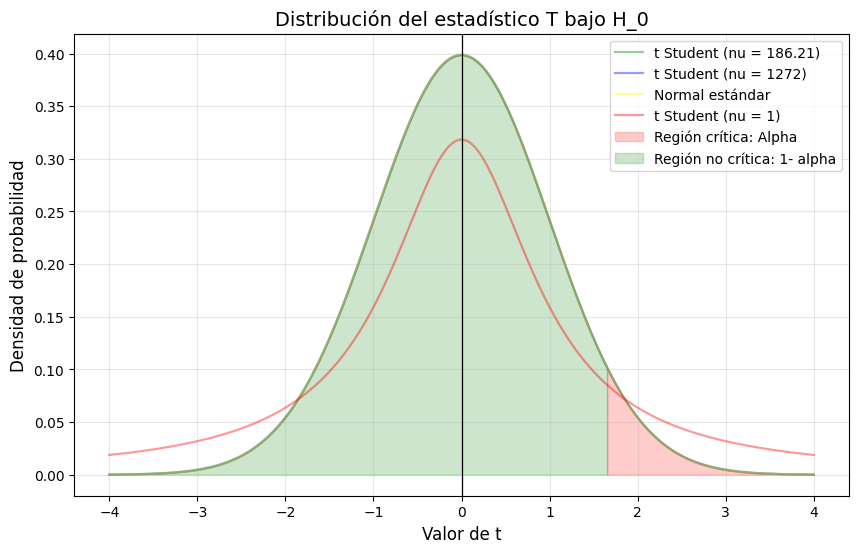

In [14]:
from scipy.stats import norm
x = np.linspace(-4, 4, 200)

y_t_hetero = t.pdf(x, nu)
y_t_homo = t.pdf(x,1272)
y_t_norm = norm.pdf(x,0,1)
y_t_pequenia = t.pdf(x,1)

plt.figure(figsize=(10, 6))
plt.plot(x, y_t_hetero, label=f't Student (nu = {186.21})', color='green', linewidth=1.6,alpha=0.4)
plt.plot(x, y_t_homo, label=f't Student (nu = {1272})', color='blue', linewidth=1.6,alpha=0.4)
plt.plot(x, y_t_norm, label=f'Normal estándar', color='yellow', linewidth=1.6,alpha=0.4)
plt.plot(x, y_t_pequenia, label=f't Student (nu = {1})', color='red', linewidth=1.6,alpha=0.4)

plt.title('Distribución del estadístico T bajo H_0', fontsize=14)
plt.xlabel('Valor de t', fontsize=12)
plt.ylabel('Densidad de probabilidad', fontsize=12)
plt.axvline(0, color='black', linewidth=0.9)

extremo_izquierdo = -4
extremo_derecho = 4

x_sombra_crit = np.linspace(extremo_derecho, t_crit, 500)
y_sombra_crit = stats.t.pdf(x_sombra_crit, df=nu)
plt.fill_between(x_sombra_crit, y_sombra_crit, color='red', alpha=0.2,
                 label=f'Región crítica: Alpha')
x_sombra = np.linspace(t_crit, extremo_izquierdo, 500)
y_sombra = stats.t.pdf(x_sombra, df=nu)
plt.fill_between(x_sombra, y_sombra, color='green', alpha=0.2,
                 label=f'Región no crítica: 1- alpha')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Como vemos, no existe diferencia entre las tres primeras gráficas; o sea, en todos los casos (tanto varianza conocida como desconocida) el intervalo de confianza es **el mismo**: esto ocurre por el Teorema del Límite Central, de modo que la muestra es tan grande que se puede aproximar a una normal con parámetros (0,1). La diferencia se evidencia en la gráfica roja, donde tenemos una t-student con 1 grado de libertad, la cual sí es diferente.

### 2. Segundo test: Significancia de la correlación de Pearson

Antes de llevar a cabo el test de hipótesis, se realiza una preparación de los datos que serán utilizados en el análisis. Como la pregunta de investigación se enfoca en países con un IDH superior al promedio, en primer lugar se seleccionan únicamente los registros que cumplen con esta condición.

Luego, se eliminan los registros que presentan valores faltantes en las variables Escolaridad y Expectativa de vida, ya que el coeficiente de correlación de Pearson requiere pares completos de observaciones para su cálculo.

In [15]:
media_idh = df_original['Income composition of resources'].mean()

df_sobreprom = df_original[
    df_original['Income composition of resources'] > media_idh
]

datos_pearson = df_sobreprom[
    ['Schooling', 'Life expectancy ']
].dropna()

print("Cantidad de datos para el test 2:", len(datos_pearson))

Cantidad de datos para el test 2: 1630


Una vez preparados los datos, se analizará la relación entre los años de escolaridad promedio y la expectativa de vida en aquellos países cuyo IDH es superior al promedio. Esto se encuentra directamente relacionado con la pregunta de investigación planteada, ya que busca determinar de qué manera los años de escolaridad influyen en la expectativa de vida dentro de países con mayores niveles de desarrollo.

En las experiencias anteriores ya se observaron indicios de una relación positiva entre ambas variables. Al estudiar la pendiente entre los años de escolaridad y la esperanza de vida, se obtuvo un valor positivo, lo que sugiere que los países con más años de educación tienden a presentar una mayor expectativa de vida. Sin embargo, esta observación por sí sola no permite asegurar que dicha relación exista en la población, por lo que es necesario realizar un test de hipótesis que permita respaldar estadísticamente esta afirmación.

Debido a que tanto la escolaridad como la expectativa de vida corresponden a variables cuantitativas continuas, se utilizará un test de significancia para el coeficiente de correlación de Pearson. Este test permitirá evaluar si existe evidencia suficiente para afirmar que ambas variables presentan una relación lineal positiva en los países con IDH superior al promedio.

**Hipotesis:** Existe una relación lineal positiva entre los años de escolaridad promedio y la esperanza de vida en países con un IDH superior al promedio.

Se define como ρ al coeficiente de correlación poblacional entre las variables Escolaridad y Expectativa de vida, entonces la hipótesis es:

$H_0$: ρ = 0

$H_1$: ρ > 0

donde:

ρ representa la correlación poblacional entre los años de escolaridad promedio y la esperanza de vida.

$H_0$ establece que no existe una relación lineal entre ambas variables.

$H_1$ establece que existe una relación lineal positiva entre los años de escolaridad promedio y la esperanza de vida.

**Supuestos:**


A diferencia del primer test, en este caso no se compararán medias entre grupos, sino que se estudiará la relación existente entre los años de escolaridad y la esperanza de vida. Por lo que la clasificación entre varianza conocida o desconocida no tiene un papel tan relevante como en el test anterior. En cambio, se utilizará un estadístico que permite evaluar si la correlación observada entre ambas variables es suficientemente grande como para concluir que existe una relación positiva entre ellas.


Para llevar a cabo este test se asumirán los siguientes supuestos:

* Las observaciones son independientes entre sí.
* La relación entre los años de escolaridad y la esperanza de vida es aproximadamente lineal.
* Las variables presentan una distribución aproximadamente normal o la muestra es suficientemente grande para que el Teorema Central del Límite permita realizar inferencias válidas.


**Estadísticos de contraste:**

Como se busca evaluar la significancia del coeficiente de correlación de Pearson, se utilizará el siguiente estadístico de contraste:

$$
T=
\frac{r\sqrt{n-2}}
{\sqrt{1-r^2}}
$$

en el que:

* $r$ corresponde al coeficiente de correlación de Pearson calculado a partir de la muestra.
* $n$ corresponde al tamaño muestral.

Bajo la hipótesis nula $H_0$, este estadístico sigue una distribución t-Student con $n-2$ grados de libertad:

$$
T \sim t_{n-2}
$$



**Nivel de significancia:**

Se trabajará con un nivel de significancia:

α=0.05

lo que corresponde a un nivel de confianza del 95%. De esta forma, se aceptará una probabilidad máxima del 5% de rechazar la hipótesis nula cuando esta sea verdadera.

**Ejecución y resultados:**

A continuación, se calculará el coeficiente de correlación de Pearson para los datos seleccionados, el cual permitirá medir la relación existente entre los años de escolaridad y la esperanza de vida.

In [ ]:
from scipy.stats import pearsonr

r, p_bilateral = pearsonr(
    datos_pearson['Schooling'],
    datos_pearson['Life expectancy ']
)

print("Coeficiente de correlación:", r)

Coeficiente de correlación: 0.611737607287861


Se obtuvo un coeficiente de correlación de Pearson de r=0.6117. Dado que este valor es positivo y relativamente cercano a 1, se observa una relación lineal positiva de magnitud moderada a fuerte entre los años de escolaridad y la esperanza de vida. Esto sugiere que los países con una mayor cantidad de años de educación tienden a presentar una mayor expectativa de vida.

Una vez calculado el coeficiente de correlación de Pearson, es posible obtener una primera aproximación sobre la relación existente entre las variables estudiadas. Pero para determinar si dicha relación es estadísticamente significativa, es necesario calcular el estadístico de contraste asociado al test. Este valor permitirá comparar la correlación observada en la muestra con lo esperado bajo la hipótesis nula y, luego, determinar si existe evidencia suficiente para rechazarla.

In [ ]:
n = len(datos_pearson)

t0 = (r * np.sqrt(n - 2)) / np.sqrt(1 - r**2)

print("T0 =", t0)

T0 = 31.20200824393242


Utilizando el coeficiente de correlación obtenido antes y el tamaño de la muestra, se calculó el estadístico de contraste asociado al test de significancia de Pearson. El valor observado fue:

$T_0 = 31.20$

Este valor representa qué tan alejada se encuentra la correlación observada respecto de lo esperado bajo la hipótesis nula $H_0$. Mientras mayor sea su magnitud, mayor será la evidencia en contra de $H_0$.

In [16]:
from scipy.stats import t

nu = n - 2

t_crit = t.ppf(0.95, df=nu)

print("Valor crítico:", t_crit)
print("Grados de libertad:", nu)

Valor crítico: 1.6454369843207466
Grados de libertad: 2613


Una vez obtenido el estadístico de contraste, se calculará el p-value asociado al test. Este valor permitirá cuantificar la evidencia existente en contra de la hipótesis nula y determinar si la relación observada entre los años de escolaridad y la esperanza de vida puede considerarse estadísticamente significativa.

In [17]:
from scipy.stats import t

p_value = 1 - t.cdf(t0, df=nu)

print("p-value =", p_value)

p-value = 0.00027139039273937904


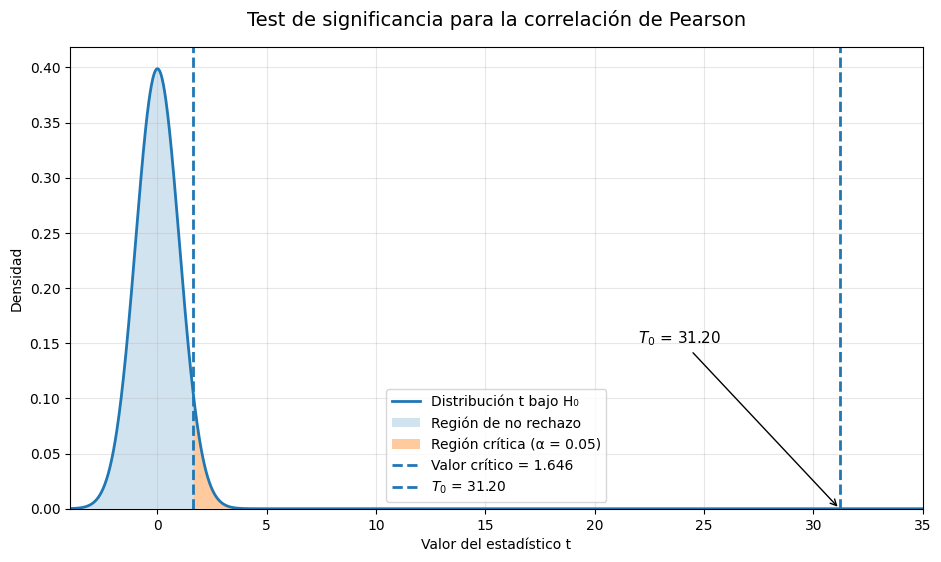

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Distribución bajo H0
x = np.linspace(-4, 35, 2000)
y = t.pdf(x, df=nu)

plt.figure(figsize=(11,6))

# Curva principal
plt.plot(x, y, linewidth=2, label='Distribución t bajo H₀')

# Región no crítica
x_nc = np.linspace(-4, t_crit, 1000)
plt.fill_between(
    x_nc,
    t.pdf(x_nc, df=nu),
    alpha=0.2,
    label='Región de no rechazo'
)

# Región crítica
x_rc = np.linspace(t_crit, 35, 1000)
plt.fill_between(
    x_rc,
    t.pdf(x_rc, df=nu),
    alpha=0.4,
    label='Región crítica (α = 0.05)'
)

# Valor crítico
plt.axvline(
    t_crit,
    linestyle='--',
    linewidth=2,
    label=f'Valor crítico = {t_crit:.3f}'
)

# Estadístico observado
plt.axvline(
    t0,
    linestyle='--',
    linewidth=2,
    label=f'$T_0$ = {t0:.2f}'
)

# Flecha apuntando a T0
plt.annotate(
    f'$T_0$ = {t0:.2f}',
    xy=(t0, t.pdf(t0, df=nu)),
    xytext=(22, 0.15),
    arrowprops=dict(arrowstyle='->'),
    fontsize=11
)

plt.title(
    'Test de significancia para la correlación de Pearson',
    fontsize=14,
    pad=15
)

plt.xlabel('Valor del estadístico t')
plt.ylabel('Densidad')
plt.xlim(-4, 35)
plt.ylim(bottom=0)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

El p-value obtenido fue prácticamente cero, lo que indica que sería extremadamente poco probable observar una correlación tan alta como la encontrada si en realidad no existiera una relación entre los años de escolaridad y la esperanza de vida. Además, el estadístico observado $T_0 = 31.20$ supera ampliamente el valor crítico obtenido para el nivel de significancia seleccionado $t_{(0.95,1628)} = 1.645$.

Debido a esto, se rechaza la hipótesis nula $H_0$.

Por lo tanto, existe evidencia estadística suficiente para afirmar que los años de escolaridad y la esperanza de vida presentan una relación lineal positiva en los países con IDH superior al promedio.

Esta conclusión también puede apreciarse visualmente en el gráfico, donde el valor observado $T_0$ se ubica ampliamente dentro de la región crítica y muy alejado del valor crítico de referencia, reforzando la evidencia en contra de la hipótesis nula.


**Errores tipo I y II**


En el contexto de este análisis, un error de tipo I ocurriría si se concluye que existe una relación lineal positiva entre los años de escolaridad y la esperanza de vida, cuando en realidad dicha relación no existe en la población de países con IDH superior al promedio.

Por otro lado, un error de tipo II ocurriría si se concluye que no existe evidencia suficiente para afirmar una relación positiva entre ambas variables, cuando en realidad sí existe una relación de este tipo en la población.

Dado que se trabajó con un nivel de significancia ($\alpha = 0.05$), existe un 5% de probabilidad de cometer un error de tipo I. La probabilidad de cometer un error de tipo II depende de diversos factores, como el tamaño de la muestra y la magnitud real de la relación entre las variables.

Consideramos que el error de tipo I es más grave en este caso, ya que implicaría afirmar la existencia de una relación entre escolaridad y esperanza de vida cuando esta realmente no existe. Esto podría llevar a interpretar erróneamente el efecto de la educación sobre la calidad de vida de los países. En cambio, cometer un error de tipo II significaría no detectar una relación que sí está presente, dejando pasar información relevante, pero sin llegar a sostener una conclusión incorrecta.



**Comparación entre varianza conocida y desconocida**

Aunque en este análisis no se trabajó directamente con una media poblacional, es posible discutir cómo afecta el supuesto de varianza conocida o desconocida al construir intervalos de confianza.

Cuando la varianza poblacional es conocida, se utiliza la distribución normal estándar para calcular los intervalos de confianza. En cambio, cuando la varianza es desconocida, se utiliza la distribución t de Student, la cual considera la incertidumbre adicional que existe al estimar la variabilidad a partir de la muestra.

La principal diferencia es que los intervalos construidos con la distribución t suelen ser un poco más amplios, especialmente cuando se trabaja con muestras pequeñas. Sin embargo, a medida que aumenta el tamaño de la muestra, la distribución t se vuelve cada vez más parecida a la distribución normal.

En nuestro caso se trabajó con una muestra muy grande ($n = 1630$), por lo que la diferencia entre ambos enfoques resulta prácticamente imperceptible. En consecuencia, los intervalos de confianza obtenidos serían muy similares tanto si se asume varianza conocida como si se considera desconocida.

Esto puede observarse en el gráfico comparativo, donde la distribución t utilizada en el análisis prácticamente coincide con la distribución normal estándar debido al gran tamaño de la muestra.


## Regresión

En función de la pregunta de investigación, realizaremos una regresión lineal entre los años de escolaridad promedio y la esperanza de vida. Como tal, la escolaridad será la variable independiente X y la esperanza de vida la dependiente Y.

Queremos obtener una relación entre las variables según una recta, de la forma:

$y = mx + b$

Donde $m$ es la pendiente de la recta, $b$ el intercepto en el eje $y$, y $x$ e $y$ ya se han detallado.

A través del método de los cuadrados ordinarios (MCO), lograremos estimar tanto el valor de $m$ como $b$. El objetivo del MCO es minimizar la suma de las diferencias al cuadrado de los valores reales (datos) y los predichos con la regresión.

Para $m$, la fórmula es:

$m = \rho_{x,y}$ ${s_y}\over{s_x}$

Donde $\rho_{x,y}$ es el factor de correlación entre las variables, y $s$ refiere a la desviación estándar de X e Y, cada una.

En cuanto a $b$, se obtiene con:

$b$ = $\overline Y - m\overline X$, (que es el despeje de la ecuación)

Dado esto, nuestro valor de $m$ es:

In [18]:
# df_filtro tiene a los países con IDH mayor a la media mundial (dentro del dataset)

desv_x = df_filtro['Schooling'].std()
desv_y = df_filtro['Life expectancy '].std()

corr = df_filtro['Life expectancy '].corr(df_filtro['Schooling'])

m = corr*(desv_y/desv_x)

print("La pendiente de la regresión es: ",m)

La pendiente de la regresión es:  1.4577560912097172


Y $b$:

In [19]:
media_x = df_filtro['Schooling'].mean()

media_y = df_filtro['Life expectancy '].mean()

b = media_y - (m*media_x)
print("El intercepto de la regresión es: ",b)

El intercepto de la regresión es:  54.86150135013382


Así, obtenemos una regresión de la forma:

$y = 1,46x + 54,86$

Lo que puede interpretarse como que un aumento en una unidad de años educativos promedio para un país se asocia a un aumento en 1,46 años de expectativa de vida. Por otro lado, podría decirse que cuando los años de educación son 0, la esperanza de vida toma un valor de 54,86; sin embargo, en nuestro contexto, debemos tener cuidado al hacer esta afirmación, ya que debemos entender si un escenario tal es posible en el conjunto de países filtrados (o sea, si tenemos a los países con un IDH relativamente alto, podría tener 0 años de escolaridad? si, pero podrían ser casos aislados).

Es importante destacar que este modelo está construido para el grupo de países como los que utilizamos en su creación, o sea, no dará buenas estimaciones en aquellos con un IDH no alto (según la clasificación de la PNUD).

In [20]:
df_reg = df_sobreprom[['Schooling', 'Life expectancy ']].dropna()
x = df_reg['Schooling']
y = df_reg['Life expectancy ']
#Para facilitar el calculo de R^2 y p-value, usamos linregress de la libreria scipystats
resultado = linregress(x, y)
r_cuadrado = resultado.rvalue ** 2
print(f"R cuadrado (R^2): {r_cuadrado:.4f}")
print(f"Valor p de la pendiente: {resultado.pvalue:.4e}")

R cuadrado (R^2): 0.3742
Valor p de la pendiente: 6.2323e-168


#***Métricas relevantes y su análisis***
El valor 0,3742 de $R^2$ significa que un 37,42% de la variación en la expectativa de vida de los países de nuestra muestra está explicada directamente por los años de escolaridad, esto es coherente y tiene sentido porque la expectativa de vida es multicausal y no depende solo de la educacion.

Por otro lado, nuestro p-value ($6.23e-168$) al ser significativamente mas bajo que cualquier nivel de significancia estandar(como el $\alpha = 0.05$ que usamos), nos permite rechazar la hipotesis nula, esto confirma que la relacion encontrada entre la escolaridad y la expectativa de vida es estadisticamente significativa.


##***Análisis I.C y Test de hipótesis***
Al contrastar los resultados, se observa una armonía muy clara entre las tres herramientas estadísticas utilizadas. La pendiente estimada originalmente en la regresión lineal es de $1.46$. Al compararla con nuestro intervalo de confianza al $95.4%$ calculado por Bootstrap ($[1.467,  1.647]$), es posible notar que el valor original se ubica justo al borde del límite inferior. Esta pequeña discrepancia en los decimales es un comportamiento esperable en datos reales al usar re-muestreo con reposición, pero en la práctica, ambos enfoques concuerdan perfectamente en que el impacto base es de aproximadamente $1.46$ años de expectativa de vida por cada año de escolaridad.Esta coherencia respalda de forma directa el resultado de nuestro test de hipótesis. Como el test rechazó la posibilidad de que la pendiente fuera cero, se confirma de manera sólida que la relación entre ambas variables es lineal y positiva.

El hecho de que todo el intervalo de confianza —incluso en su extremo más bajo ($1.467$)— se mantenga estrictamente por encima de cero, es una prueba independiente que valida y refuerza la decisión tomada en el test de hipótesis.En conclusión, las tres metodologías se apoyan mutuamente con éxito: la regresión nos entrega el valor puntual, el intervalo delimita con precisión el escenario mínimo de ese impacto, y el test valida que la dirección de la relación es estadísticamente significativa. Este alineamiento le otorga una gran solidez a las conclusiones finales de nuestro estudio.

##**Limitaciones del modelo**


Si bien la regresión lineal permite describir la relación observada entre los años de escolaridad y la esperanza de vida, es importante considerar algunas limitaciones antes de interpretar los resultados.

En primer lugar, el modelo utiliza únicamente la escolaridad como variable explicativa. Sin embargo, la esperanza de vida también puede verse influenciada por numerosos factores que no fueron incorporados en el análisis, como el acceso a servicios de salud, las condiciones económicas, el nivel de desarrollo sanitario o las políticas públicas de cada país.

Además, aunque el modelo identifica una relación positiva entre ambas variables, esto no implica necesariamente una relación de causa y efecto. Los resultados permiten afirmar que existe una asociación entre escolaridad y esperanza de vida, pero no demostrar que una variable sea la causa directa de la otra.

Por otra parte, el análisis fue realizado únicamente sobre países con un IDH superior al promedio. Debido a esto, las conclusiones obtenidas no necesariamente pueden extrapolarse a países con menores niveles de desarrollo.

##**Fuentes de sesgo**

Una posible fuente de sesgo proviene del criterio de selección utilizado para los datos, ya que únicamente se consideraron países con un IDH superior al promedio. Esto reduce la representatividad de la muestra respecto al conjunto completo de países.

Además, el conjunto de datos contiene observaciones correspondientes a distintos países y distintos años. Como consecuencia, pueden existir diferencias temporales o características propias de cada país que no son consideradas explícitamente por el modelo.

También podría existir sesgo por variables omitidas. Factores como el ingreso económico, la inversión en salud, la mortalidad infantil o la calidad de los sistemas educativos pueden influir simultáneamente tanto en la escolaridad como en la esperanza de vida, generando parte de la relación observada.

Finalmente, la existencia de errores de medición o diferencias en la calidad de los registros reportados por distintos países podría afectar parcialmente los resultados obtenidos, introduciendo variabilidad adicional en el análisis.



##**Residuos vs valores ajustados**

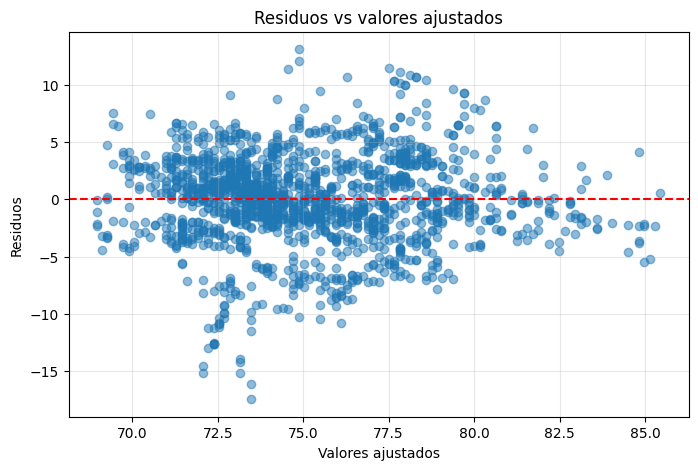

In [21]:
# Valores ajustados
y_ajustado = resultado.intercept + resultado.slope * x

# Residuos
residuos = y - y_ajustado

plt.figure(figsize=(8,5))
plt.scatter(y_ajustado, residuos, alpha=0.5)

plt.axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=1.5
)

plt.title('Residuos vs valores ajustados')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.grid(alpha=0.3)

plt.show()

Este gráfico permite evaluar si la regresión lineal utilizada representa adecuadamente la relación entre los años de escolaridad y la esperanza de vida. En términos generales, se espera que los residuos se distribuyan alrededor de cero sin seguir un patrón definido.

Como puede observarse, los residuos se encuentran relativamente dispersos alrededor de la línea horizontal ubicada en cero y no presentan una tendencia clara. Esto sugiere que el modelo lineal utilizado resulta adecuado para describir la relación entre ambas variables.

Sin embargo, también se observa cierta variabilidad en los residuos y algunos valores más alejados del resto, lo que indica que la esperanza de vida no depende únicamente de los años de escolaridad. Existen otros factores que probablemente influyen en esta variable y que no están siendo considerados en el modelo.

A pesar de ello, el gráfico no muestra evidencias claras de problemas importantes en el ajuste realizado, por lo que la regresión lineal puede considerarse una aproximación razonable para los datos analizados.

## Bonus: Regresión con Scikit-learn

Scikit-learn es una librería de Python usada principalmente para el aprendizaje automático (Machine Learning). Dentro de sus funcionalidades, se encuentra la Regresión, para poder predecir el atributo de un objeto.

### Regresión lineal

Así, en el contexto de nuestro problema, utilizaremos esta librería para poder replicar la regresión realizada en el punto anterior, pero con un método de aprendizaje automático. De esta forma:

In [22]:
import sklearn #Importamos la librería
from sklearn.model_selection import train_test_split #Importamos la función de dividir los datos
from sklearn.linear_model import LinearRegression #Importamos la función de Regresión lineal
from sklearn.metrics import r2_score

X = df_filtro[['Schooling']]
y = df_filtro['Life expectancy ']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Separamos los datos en 80% para entrenar y 20% para testear

modelo = LinearRegression()
modelo.fit(X_train, y_train) #Aplicamos regresión linear con datos entrenados

m_entrenada = modelo.coef_[0] #La pendiente del modelo
b_entrenada = modelo.intercept_ #El intercepto del modelo

print("La pendiente con sklearn es: ",m_entrenada)
print("El intercepto con sklearn es: ",b_entrenada)

y_pred = modelo.predict(X_test) #Predicción hecha por el modelo entrenado de los valores que no conoce

r2 = r2_score(y_test, y_pred) #Diferencia entre los valores predecidos y los reales

print("El valor de r2 con sklearn es: ",r2)

La pendiente con sklearn es:  1.468273669912586
El intercepto con sklearn es:  54.69297001341933
El valor de r2 con sklearn es:  0.3684288751510115


Básicamente, tomamos ambas variables y las separamos: el 80% de ellas serán conocidas con por el modelo, y son las que utilizará para entrenarse, y el otro 20% están 'ocultas' y se usarán para comparar su capacidad de predicción.

Luego, se crea una regresión con el conjunto de datos de entrenamiento, obteniendo la pendiente e intercepto.

Por último, se calcula el valor de $R^2$ a través de un contraste de los valores predichos por el modelo entrenado para aquellos datos que no le entregamos, versus los valores reales.

Podemos ver que tanto la pendiente como el intercepto y el $R^2$ son casi los mismos que los que obtuvimos con el método de los cuadrados ordinarios, lo cual significa que el modelo logra predecir efectivamente sobre datos 'externos'.

### Clasificación

Ahora, llevaremos a cabo una clasificación con una regresión logística para países según su estado: Desarrollado o En Desarrollo. La definición se hará en función a tres variables: Expectativa de vida, Años de escolaridad e Ingreso per Cápita (GDP). Así:

In [23]:
from sklearn.linear_model import LogisticRegression #importamos la funcionalidad de regresión lógica
from sklearn.metrics import accuracy_score #importamos la funcionalidad de puntaje de exactitud
from sklearn.metrics import confusion_matrix #importamos la funcionalidad de matriz de confusión

df_clas = df.dropna(subset=['Status', 'Schooling', 'Life expectancy ','GDP']).copy() #Eliminamos los valores nulos y guardamos todo en un nuevo dataset
df_clas['Status_binario'] = (df_clas['Status'] == 'Developed').astype(int) #Creamos una columna nueva con el estado codificado de forma binaria donde: 0 -> Developing y 1 -> Developed
print("Número de datos: ",len(df_clas))

X = df_clas[['Schooling', 'Life expectancy ','GDP']] #Variables para entrenar al modelo (en base a qué podrá predecir el estado del país)
y = df_clas['Status_binario']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42) #Dividimos el 80% de los datos para entrenamiento y el 20% para prueba
print("Número de datos de prueba: ",(0.2*len(df_clas)))

modelo = LogisticRegression()
modelo.fit(X_train, y_train) #Hacemos un ajuste con los datos para entrenar el modelo
y_pred = modelo.predict(X_test) #Creamos la predicción

acc = accuracy_score(y_test, y_pred) #Calculamos el accuracy score
print("\nLa exactitud de la predicción del modelo es: ",acc)

matriz = confusion_matrix(y_test, y_pred) #Creamos la matriz de confusión
print("Matriz de confusión: \n",matriz)

Número de datos:  2347
Número de datos de prueba:  469.40000000000003

La exactitud de la predicción del modelo es:  0.9042553191489362
Matriz de confusión: 
 [[370  18]
 [ 27  55]]


La idea es similar a la regresión, pero los resultados que tenemos son otros:

Como la exactitud del modelo es 0.9, eso significa que el modelo ha logrado predecir correctamente el 90% de los datos de prueba en función las variables que definimos.

Además, con la matriz de connfusión podemos entender que:

-> En 370 casos, se predijo al país como 'en desarrollo' cuando sí lo era (acierto).

-> En 18 casos, se predijo al país como 'desarrollado' cuando era 'en desarrollo' (falla).

-> En 27 casos, se predijo al país como 'en desarrollo' cuando era 'desarrollado' (falla).

-> En 55 casos, se predijo al país como 'desarrollado' cuando sí lo era (acierto).